<a href="https://colab.research.google.com/github/nirmalprabhakarc/Machine-Learning-Alogarithms/blob/main/Implementation_of_Hierarchical_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


nirmal

Aim: Develop the Hierarchical Clustering model to perform Agglomerative & Divisive
Clustering, and evaluate the performance of the models.

Description:
Hierarchical clustering is an unsupervised machine learning technique used to group similar objects into clusters. It builds hierarchies of clusters by either merging or splitting clusters iteratively.


There are two main approaches to hierarchical clustering:


Agglomerative clustering: Each data point starts in its own cluster, and clusters are recursively merged as we move up the hierarchy. It is a "bottom-up" approach.

Divisive clustering: All data points start in one cluster, which is recursively split into smaller clusters as we move down the hierarchy. It is a "top-down" approach.


Agglomerative clustering is more commonly used in practice due to its simplicity.


The key steps in agglomerative hierarchical clustering are:


Compute the similarity/distance matrix between all data points.

Assign each data point to its own cluster.

Find the most similar/nearest pair of clusters and merge them into a new cluster.

Recompute similarities/distances between the new cluster and each of the old clusters.

Repeat steps 3 and 4 until all clusters have been merged into one big cluster containing all data points.


The result is a tree-like structure called a dendrogram that illustrates the fusing of clusters with increasing distance levels. We can cut/extract clusters from the dendrogram at a certain level based on domain knowledge.



In [ ]:
print("URK21CS2060")
print("Q1:Import necessary python libraries")
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, mutual_info_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

URK21CS2060
Q1:Import necessary python libraries


In [ ]:
print("URK21CS2060")
print("Q2:Read the dataset")
data = pd.read_csv('B5_wine_clustering.csv')
data

URK21CS2060
Q2:Read the dataset


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
print("URK21CS2060")
print("Q3:Standardize the data using StandardScaler")
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

URK21CS2060
Q3:Standardize the data using StandardScaler


In [ ]:
print("URK21CS2060")
print("Q4:Decide linkage approach to adopt for the clustering. Use the linkage criteria’s as single, complete and ward")
linkage_approaches = ['single', 'complete', 'ward']

URK21CS2060
Q4:Decide linkage approach to adopt for the clustering. Use the linkage criteria’s as single, complete and ward


URK21CS2060
Q5:Draw the corresponding dendrograms of the linkage approach


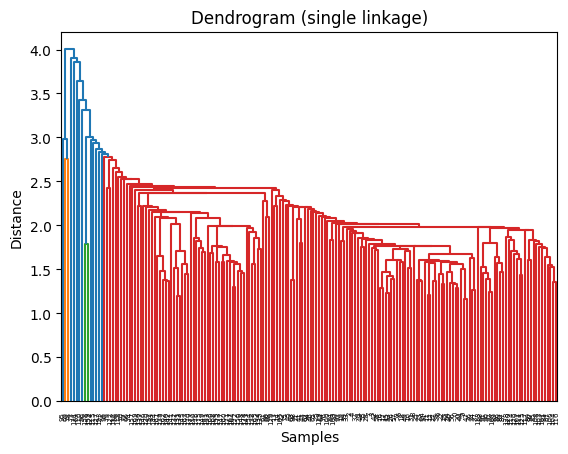

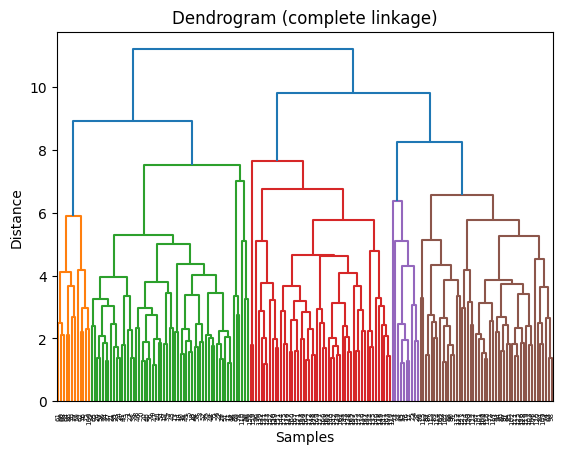

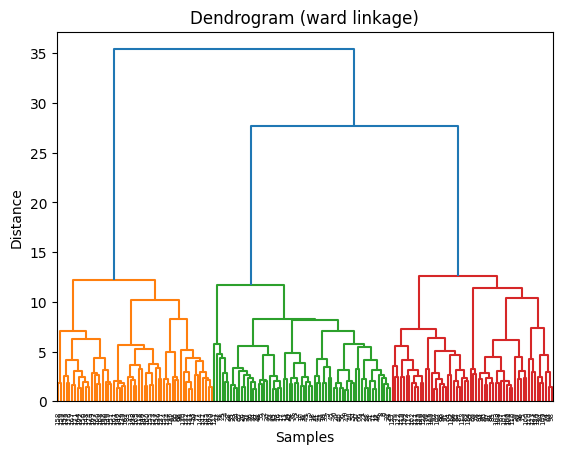

In [ ]:
print("URK21CS2060")
print("Q5:Draw the corresponding dendrograms of the linkage approach")
for approach in linkage_approaches:
    clustering = linkage(scaled_data, method=approach, metric='euclidean')
    dendrogram(clustering)
    plt.title(f'Dendrogram ({approach} linkage)')
    plt.xlabel('Samples')
    plt.ylabel('Distance')
    plt.show()

In [ ]:
print("Q6:Create a clustering model with number of clusters (3), linkage criteria (ward)")
print("URK21CS2060")
n_clusters = 3
linkage_criteria = 'ward'
clustering_model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_criteria)

Q6:Create a clustering model with number of clusters (3), linkage criteria (ward)
URK21CS2060


In [ ]:
print("URK21CS2060")
print("Q7:Fit and predict the cluster label")
cluster_labels = clustering_model.fit_predict(scaled_data)

URK21CS2060
Q7:Fit and predict the cluster label


URK21CS2060
Q8. Visualize the clusters using scatter plot ('Alcohol', 'Malic_Acid')


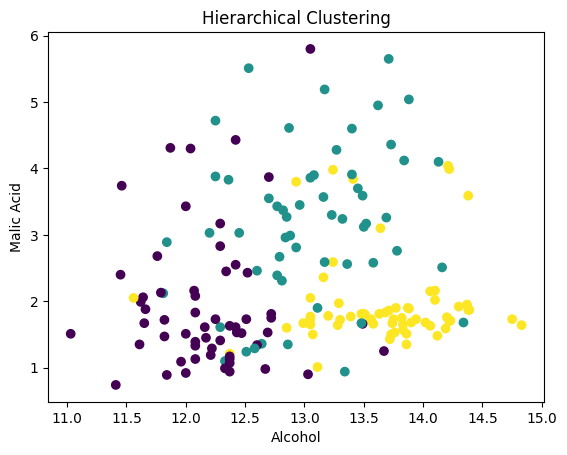

In [ ]:
print("URK21CS2060")
print("Q8. Visualize the clusters using scatter plot ('Alcohol', 'Malic_Acid')")
plt.scatter(data['Alcohol'], data['Malic_Acid'], c=cluster_labels)
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.title('Hierarchical Clustering')
plt.show()


In [ ]:
print("URK21CS2060")
print("Q9. Calculate and display the performance metrics Mutual information score (‘Alcohol’), Silhouette score, and Davies-Bouldin index")
mutual_info = mutual_info_score(data['Alcohol'], cluster_labels)
silhouette = silhouette_score(scaled_data, cluster_labels)
davies_bouldin = davies_bouldin_score(scaled_data, cluster_labels)

URK21CS2060
Q9. Calculate and display the performance metrics Mutual information score (‘Alcohol’), Silhouette score, and Davies-Bouldin index


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/cluster/_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)


In [ ]:
print("URK21CS60")
print("Q10. Create a clustering model with number of clusters (4), linkage criteria (ward)")
n_clusters = 4
clustering_model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_criteria)

URK21CS60
Q10. Create a clustering model with number of clusters (4), linkage criteria (ward)


In [ ]:
print("URK21CS2060")
print("Q11. Fit and predict the cluster label")
cluster_labels = clustering_model.fit_predict(scaled_data)

URK21CS2060
Q11. Fit and predict the cluster label


URK21CS2060
Q12.Visualize the clusters using scatter plot ('Alcohol', 'Malic_Acid')


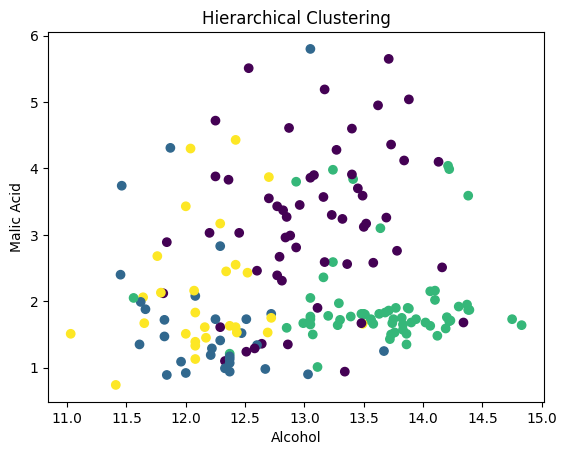

In [ ]:
print("URK21CS2060")
print("Q12.Visualize the clusters using scatter plot ('Alcohol', 'Malic_Acid')")
plt.scatter(data['Alcohol'], data['Malic_Acid'], c=cluster_labels)
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.title('Hierarchical Clustering')
plt.show()

In [ ]:
print("URK21CS2060")
print("Q13.Calculate and display the performance metrics Mutual information score (‘Alcohol’), Silhouette score, and Davies-Bouldin index")
mutual_info = mutual_info_score(data['Alcohol'], cluster_labels)
silhouette = silhouette_score(scaled_data, cluster_labels)
davies_bouldin = davies_bouldin_score(scaled_data, cluster_labels)
print(f"Mutual Information Score: {mutual_info}")
print(f"Silhouette Score: {silhouette}")
print(f"Davies-Bouldin Index: {davies_bouldin}")

URK21CS2060
Q13.Calculate and display the performance metrics Mutual information score (‘Alcohol’), Silhouette score, and Davies-Bouldin index
Mutual Information Score: 1.0728869051089787
Silhouette Score: 0.225836659334758
Davies-Bouldin Index: 1.7886506143765986


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/cluster/_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)


In [ ]:
from tabulate import tabulate

# Prepare the data
data = [
    ["Mutual Information Score", mutual_info_3, mutual_info_4],
    ["Silhouette Score", silhouette_3, silhouette_4],
    ["Davies-Bouldin Index", davies_bouldin_3, davies_bouldin_4]
]

# Print the comparison using tabulate
print("URK21CS2060")
print("Q14. Compare the results of the two models in terms of performance metrics")
print("-" * 80)
print(tabulate(data, headers=["Performance Metric", "3-cluster model", "4-cluster model"], tablefmt="pipe"))


NameError: name 'mutual_info_3' is not defined

Result:
Thus to develop the Hierarchical Clustering model to perform Agglomerative & Divisive
Clustering, and evaluate the performance of the models are executed successfully